In [2]:
import numpy as np
import plotly.io as pio
pio.renderers.default = 'notebook'
import plotly.express as ex

In [3]:
#7.1 - 7.2

A = np.random.randn(400).reshape(20, 20)

A1 = A - A.mean(axis=0, keepdims=True)
kow = (A1.T @ A1) / 19

var = np.diag(np.sqrt(np.diag(kow)) ** -1)

fig1 = ex.imshow(kow, color_continuous_scale='gray', title='cov', labels=dict(x='x', y='y', color='знач'))
fig2 = ex.imshow((var @ kow @ var) - np.corrcoef(A, rowvar=False), color_continuous_scale='gray', title='corr', labels=dict(x='x', y='y', color='знач'))
fig3 = ex.imshow(np.corrcoef(A, rowvar=False), color_continuous_scale='gray', title='corr', labels=dict(x='x', y='y', color='знач'))

fig1.show()
fig2.show()
fig3.show()

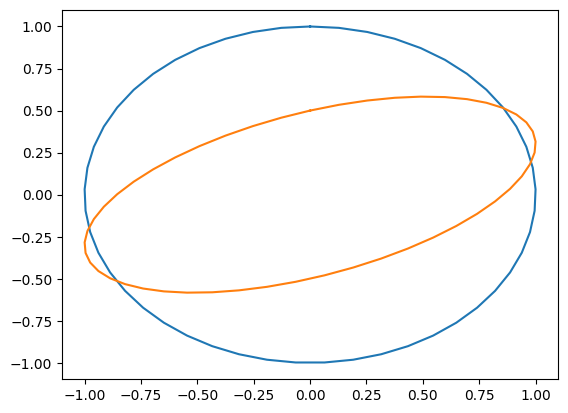

array([[ 0.00000000e+00,  1.27877162e-01,  2.53654584e-01,
         3.75267005e-01,  4.90717552e-01,  5.98110530e-01,
         6.95682551e-01,  7.81831482e-01,  8.55142763e-01,
         9.14412623e-01,  9.58667853e-01,  9.87181783e-01,
         9.99486216e-01,  9.95379113e-01,  9.74927912e-01,
         9.38468422e-01,  8.86599306e-01,  8.20172255e-01,
         7.40277997e-01,  6.48228395e-01,  5.45534901e-01,
         4.33883739e-01,  3.15108218e-01,  1.91158629e-01,
         6.40702200e-02, -6.40702200e-02, -1.91158629e-01,
        -3.15108218e-01, -4.33883739e-01, -5.45534901e-01,
        -6.48228395e-01, -7.40277997e-01, -8.20172255e-01,
        -8.86599306e-01, -9.38468422e-01, -9.74927912e-01,
        -9.95379113e-01, -9.99486216e-01, -9.87181783e-01,
        -9.58667853e-01, -9.14412623e-01, -8.55142763e-01,
        -7.81831482e-01, -6.95682551e-01, -5.98110530e-01,
        -4.90717552e-01, -3.75267005e-01, -2.53654584e-01,
        -1.27877162e-01, -2.44929360e-16],
       [ 1.00

In [ ]:
#7.3

import matplotlib.pyplot as plt 

x = np.sin(np.linspace(0, 2*np.pi, 50))
y = np.cos(np.linspace(0, 2*np.pi, 50))

for_tr = np.vstack((x, y))

T = np.array([[1, 0.3],
              [0, 0.5]]).T

res = T @ for_tr
plt.plot(x, y)
plt.plot(res[0,:], res[1,:])
plt.show()
for_tr

In [42]:
from PIL import Image
from scipy.signal import convolve2d

rgb = np.array(Image.open('image.png'))

r = rgb[:, :, 0]
g = rgb[:, :, 1]
b = rgb[:, :, 2]

fig1 = ex.imshow(b, color_continuous_scale='gray')
fig1.show()

x1, y1 = np.meshgrid(np.linspace(-0.5, 0.5, 30), np.linspace(-0.5, 0.5, 30))
x2, y2 = np.meshgrid(np.linspace(-5, 5, 30), np.linspace(-5, 5, 30))
x3, y3 = np.meshgrid(np.linspace(-50, 50, 30), np.linspace(-50, 50, 30))
kernel1 = np.exp(-(x1**2 + y1**2) / x.shape[0])
kernel1 /= np.sum(kernel1)
kernel2 = np.exp(-(x2**2 + y2**2) / x.shape[0])
kernel2 /= np.sum(kernel2)
kernel3 = np.exp(-(x3**2 + y3**2) / x.shape[0])
kernel3 /= np.sum(kernel3)

r_p = np.uint8(convolve2d(r, kernel1, mode='same'))
g_p = np.uint8(convolve2d(g, kernel2, mode='same'))
b_p = np.uint8(convolve2d(b, kernel3, mode='same'))

rc = Image.fromarray(r_p)
gc = Image.fromarray(g_p)
bc = Image.fromarray(b_p)

img = Image.merge("RGB", (rc,gc,bc))

fig1 = ex.imshow(r_p, color_continuous_scale='gray')
fig1.show()

img.show()

In [60]:
from PIL import Image
from scipy.signal import convolve2d

img = Image.open('image.png')
gr = img.convert('L')
m_img = np.array(gr)

kernel1, kernel2 = np.meshgrid(np.array([0,0, 1, 0,0]), np.array([0, 1, 0]))
print(kernel1, kernel2)
res = np.uint8(convolve2d(m_img, kernel1, mode='same'))
res = Image.fromarray(res)
res.show()

[[0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]] [[0 0 0 0 0]
 [1 1 1 1 1]
 [0 0 0 0 0]]
